# 1. DATA OVERVIEW

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [70]:
df = pd.read_csv("../1-Data/train_data.csv")
#df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             734 non-null    int64  
 1   Sex             734 non-null    object 
 2   ChestPainType   734 non-null    object 
 3   RestingBP       734 non-null    int64  
 4   Cholesterol     734 non-null    int64  
 5   FastingBS       734 non-null    int64  
 6   RestingECG      734 non-null    object 
 7   MaxHR           734 non-null    int64  
 8   ExerciseAngina  734 non-null    object 
 9   Oldpeak         734 non-null    float64
 10  ST_Slope        734 non-null    object 
 11  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 68.9+ KB


In [71]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,53.848774,132.874659,203.227520,0.228883,136.377384,0.865123,0.553134
std,9.440574,18.080330,108.402067,0.420400,25.832297,1.056964,0.497508
min,29.000000,92.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,180.000000,0.000000,119.000000,0.000000,0.000000
50%,55.000000,130.000000,225.000000,0.000000,138.000000,0.500000,1.000000
75%,61.000000,141.000000,269.750000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,5.600000,1.000000


In [72]:
df.describe(include=['O', 'object'])

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,734,734,734,734,734
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,579,403,447,434,374


In [73]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
(df['Cholesterol'] == 0).sum()

np.int64(129)

In [76]:
(df['RestingBP']==0).sum()

np.int64(0)

## Conclusion:
- There are 918 observations & 12 features (11 predictors and 1 target variable)
- No duplicated row and no null values
- Check there are 129 records of 0 colesterol. --> this is impossible for human. --> need Data Cleaning.

# 2. Univariate Analysis (Feature Distributions)

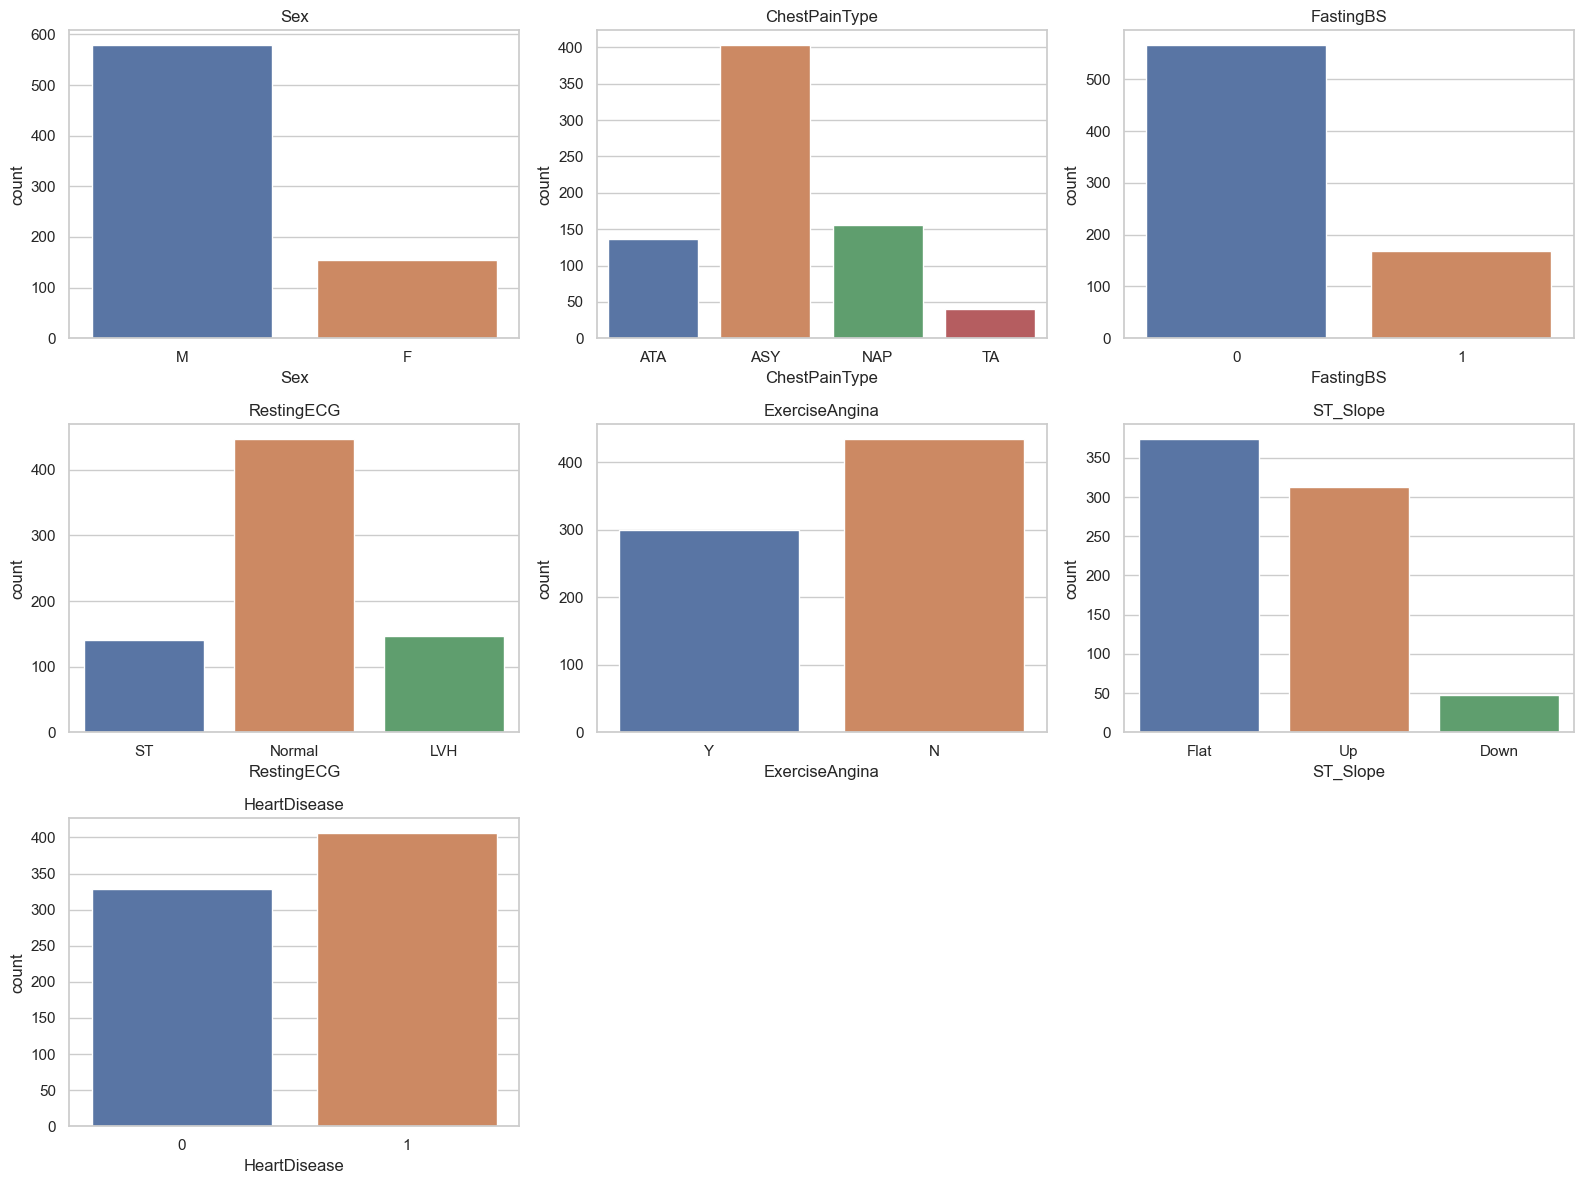

In [77]:
cols = ['Sex','ChestPainType','FastingBS', 'RestingECG','ExerciseAngina', 'ST_Slope','HeartDisease']

plt.figure(figsize=(16,12))
for i,col in enumerate(cols,1):
    plt.subplot(3,3,i)
    sns.countplot(x=col,data=df,hue=col,legend=False)
    plt.title(col)
plt.tight_layout()
plt.show()

- Target: HeartDisease (0=Normal, 1= Heart Disease) quite balance
- Focus area:
  + Sex: Male >> Female
  + ChestPainType: Asymptomatic quite high, meaning no chest pain but still have heart disease
  + ST_Slope: UP: normal, but Flat is high --> Heart lacks of oxygen and blood

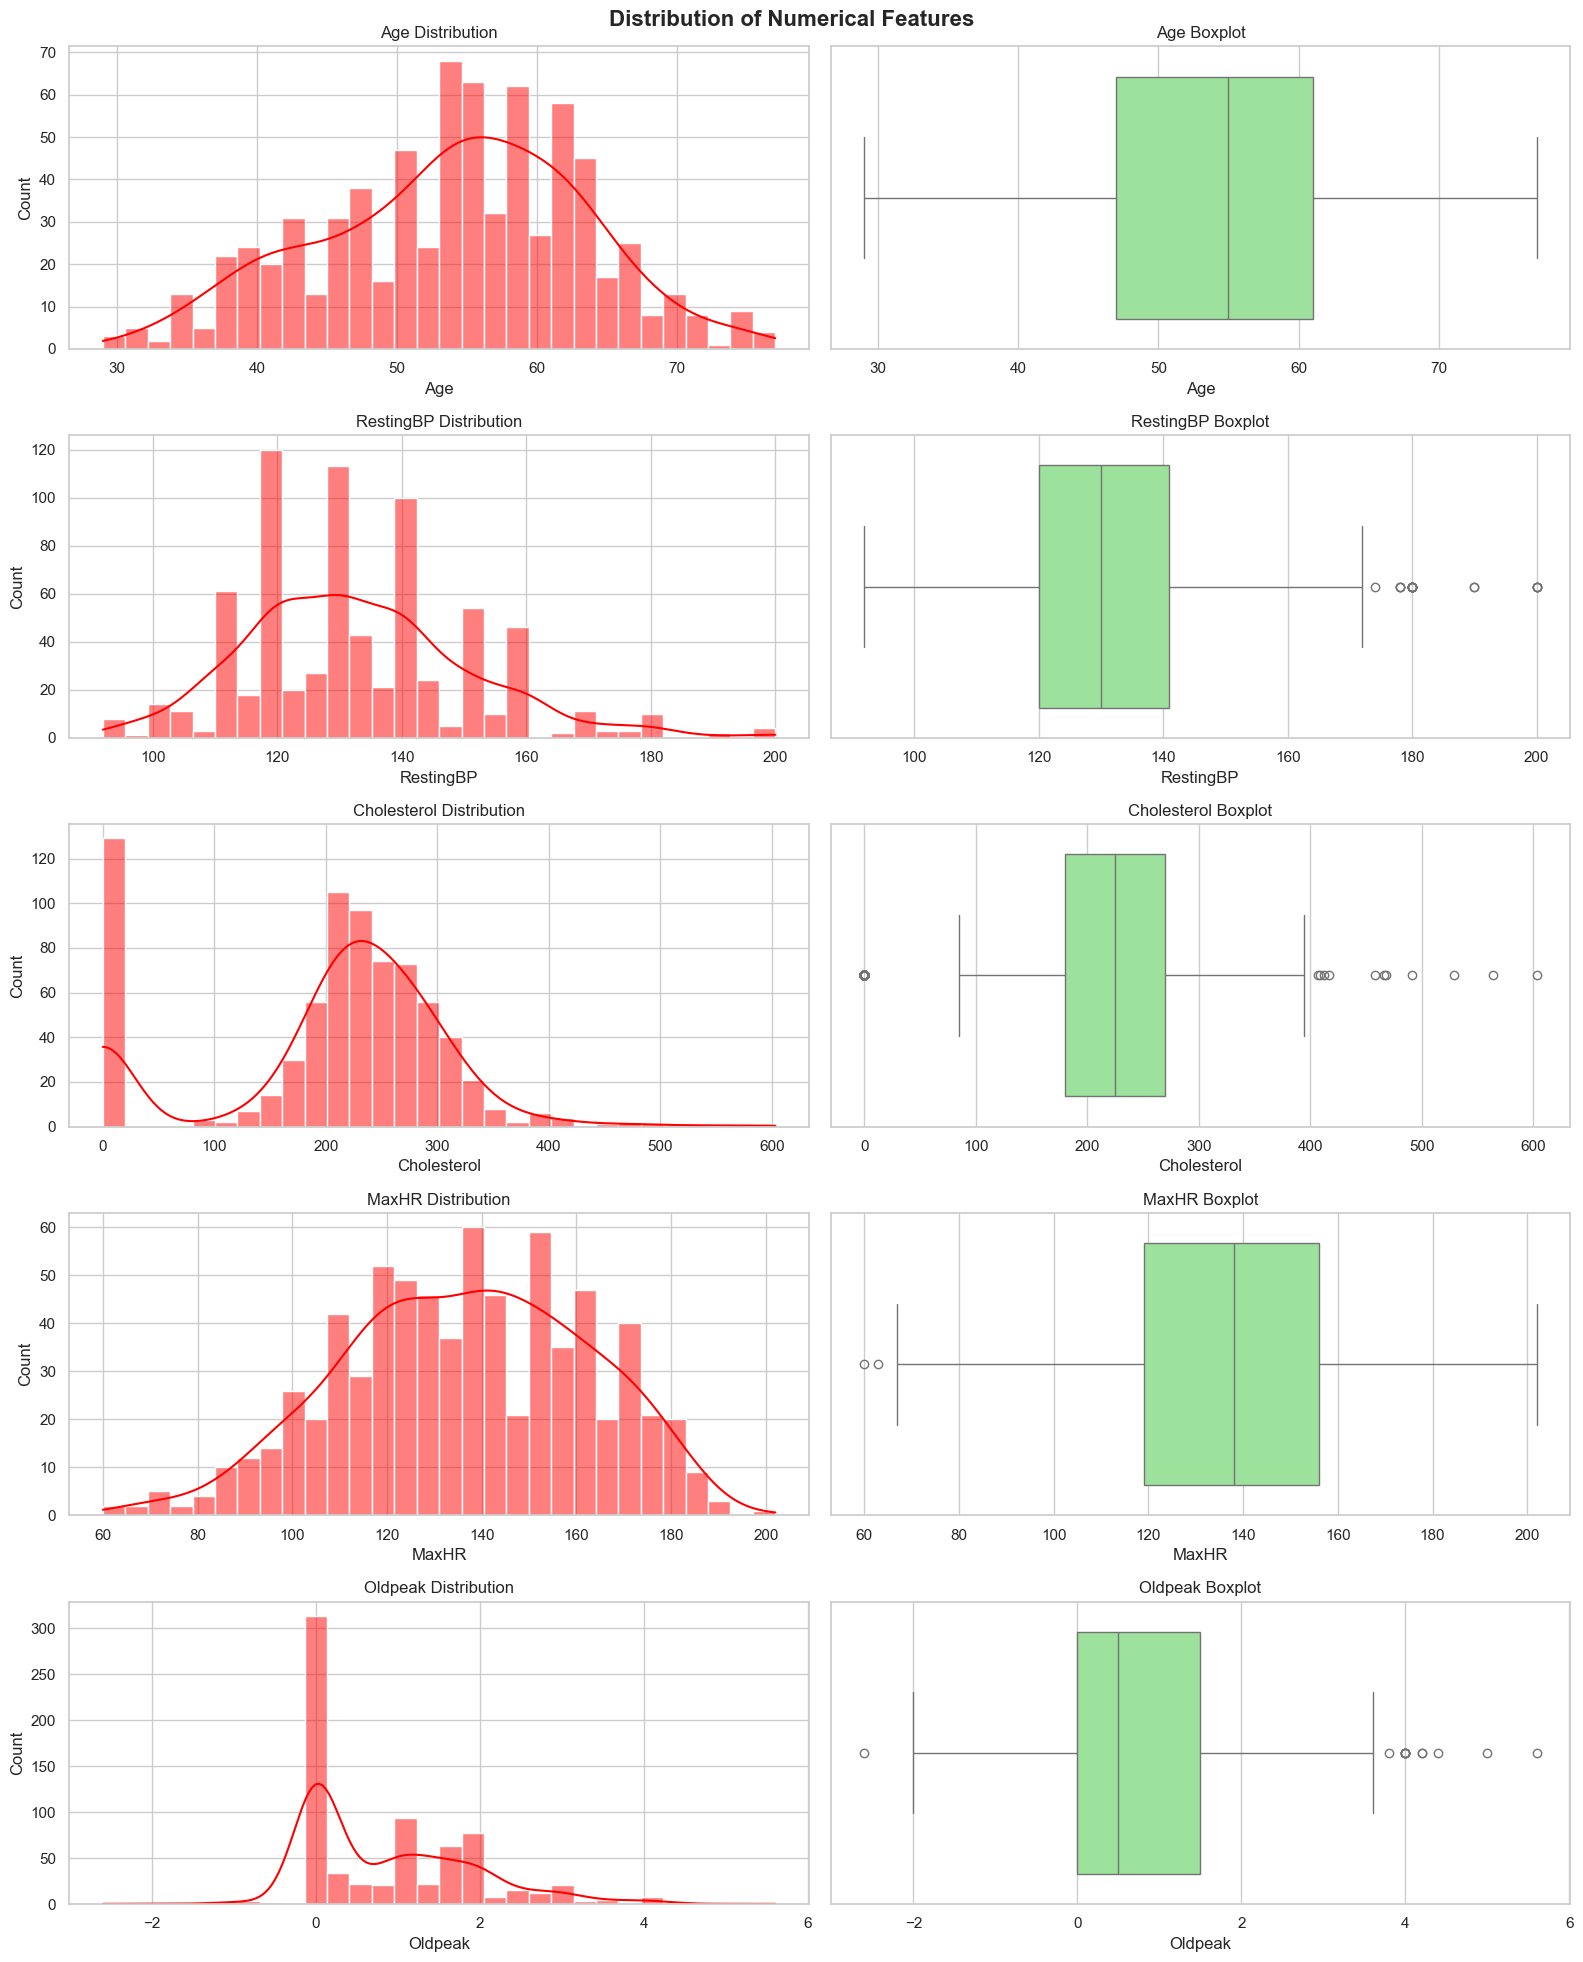

In [78]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(16, 20))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_cols):
    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color='red',
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'{col} Distribution')
    
    sns.boxplot(
        x=df[col],
        color='lightgreen',
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

- Age: Normally distributed
- RestingBP: some outliers (>180)
- Choresterol: Unnatural spike at 0.
- MaxHeartRate: A few low-end outliers (below 70) are visible in the boxplot.
- Oldpeak: ...

# 3. Bivariate Analysis (Features vs. Target)

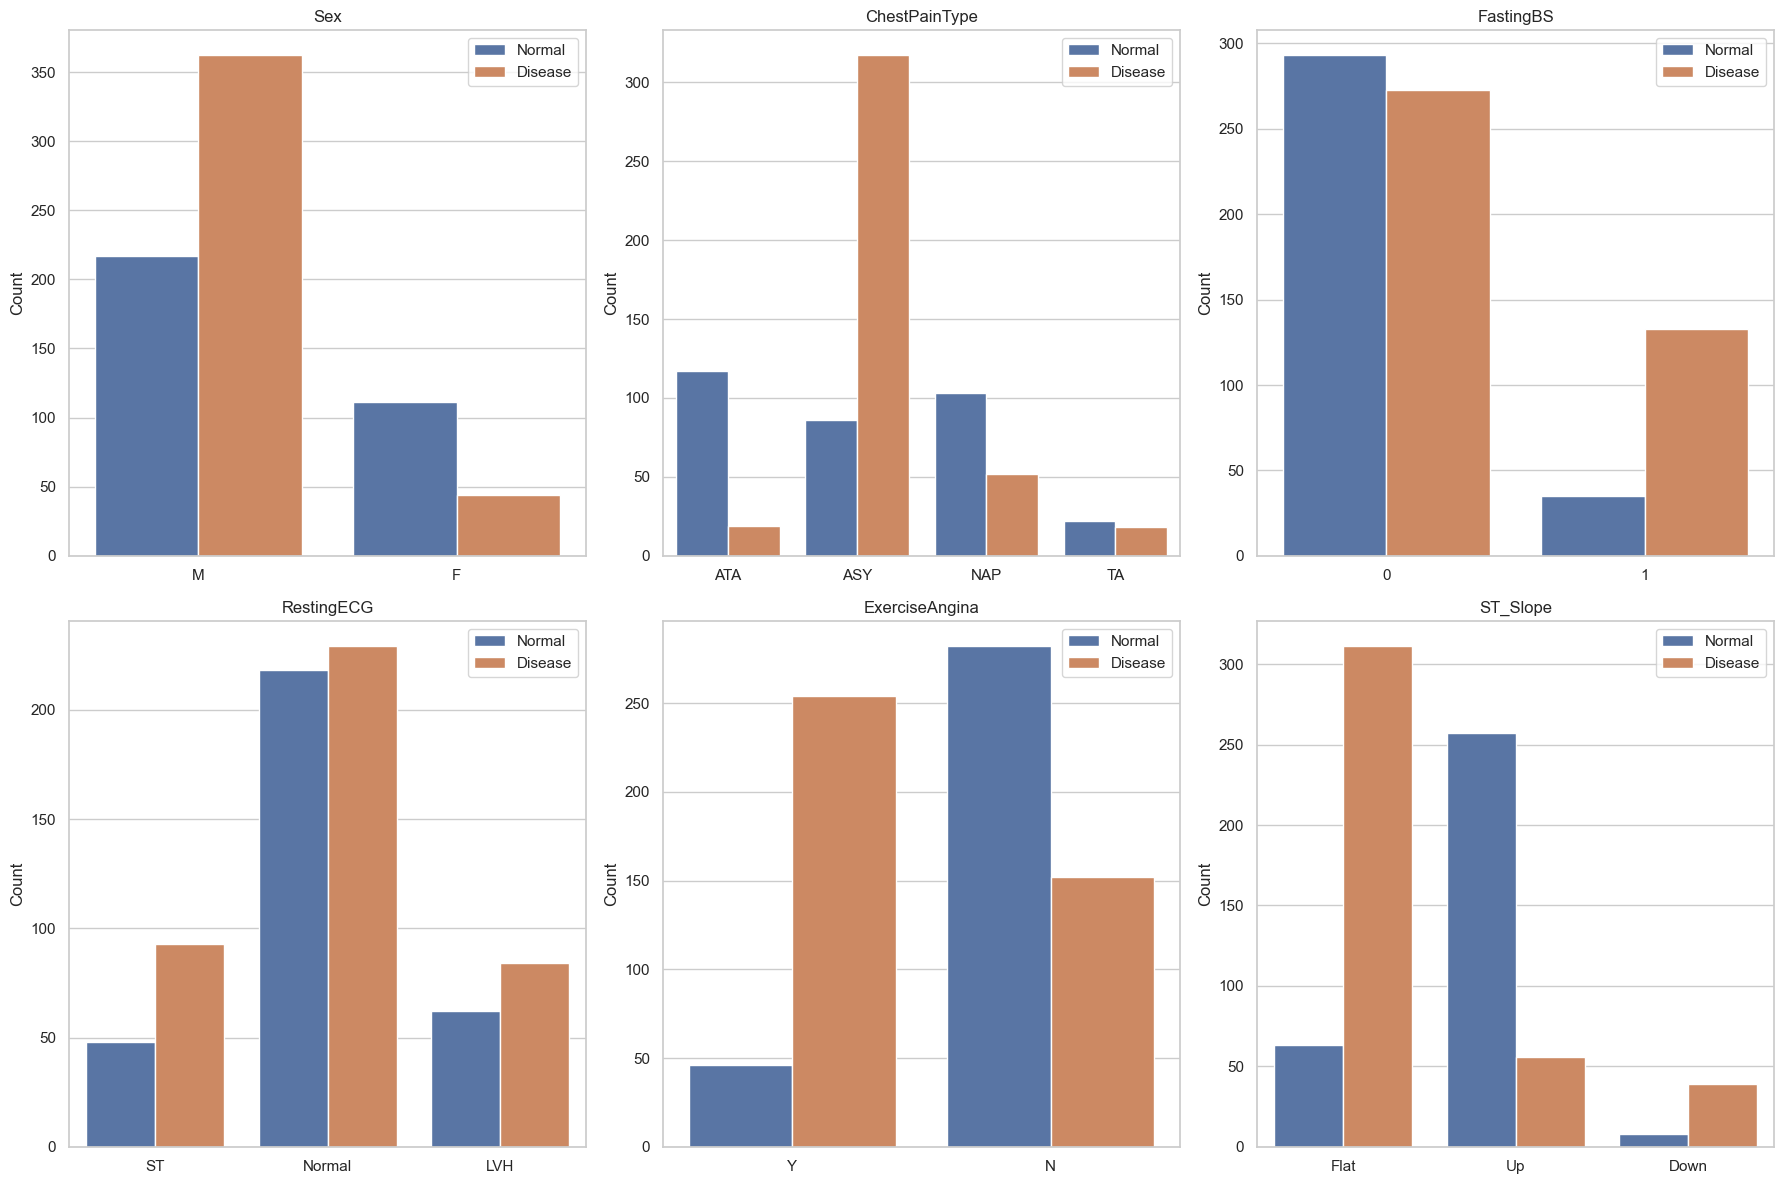

In [79]:
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(
        x=col,
        hue='HeartDisease',
        data=df,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(['Normal', 'Disease'])

plt.tight_layout()
plt.show()

Top-Tier Predictors (High Weight for the Model):
- ST_Slope: The absolute strongest separator. Flat and Down slopes heavily dominate the HeartDisease == 1 class, while Up strongly points to a healthy patient.
- ChestPainType: The ASY (Asymptomatic) category shows a massive spike in heart disease cases.
- ExerciseAngina: If Y (Yes), the likelihood of heart disease increases drastically.

Mid-Tier Predictors:
- Sex: Males (M) show a significantly higher ratio of disease compared to Females (F).
- FastingBS: A value of 1 correlates strongly with heart disease, whereas the 0 category is somewhat balanced.

Low-Tier Predictors (Weak Signal):
- RestingECG: The proportions of Normal vs. Disease are relatively close across all categories (Normal, ST, LVH). This feature provides the least discriminative power for the algorithm.

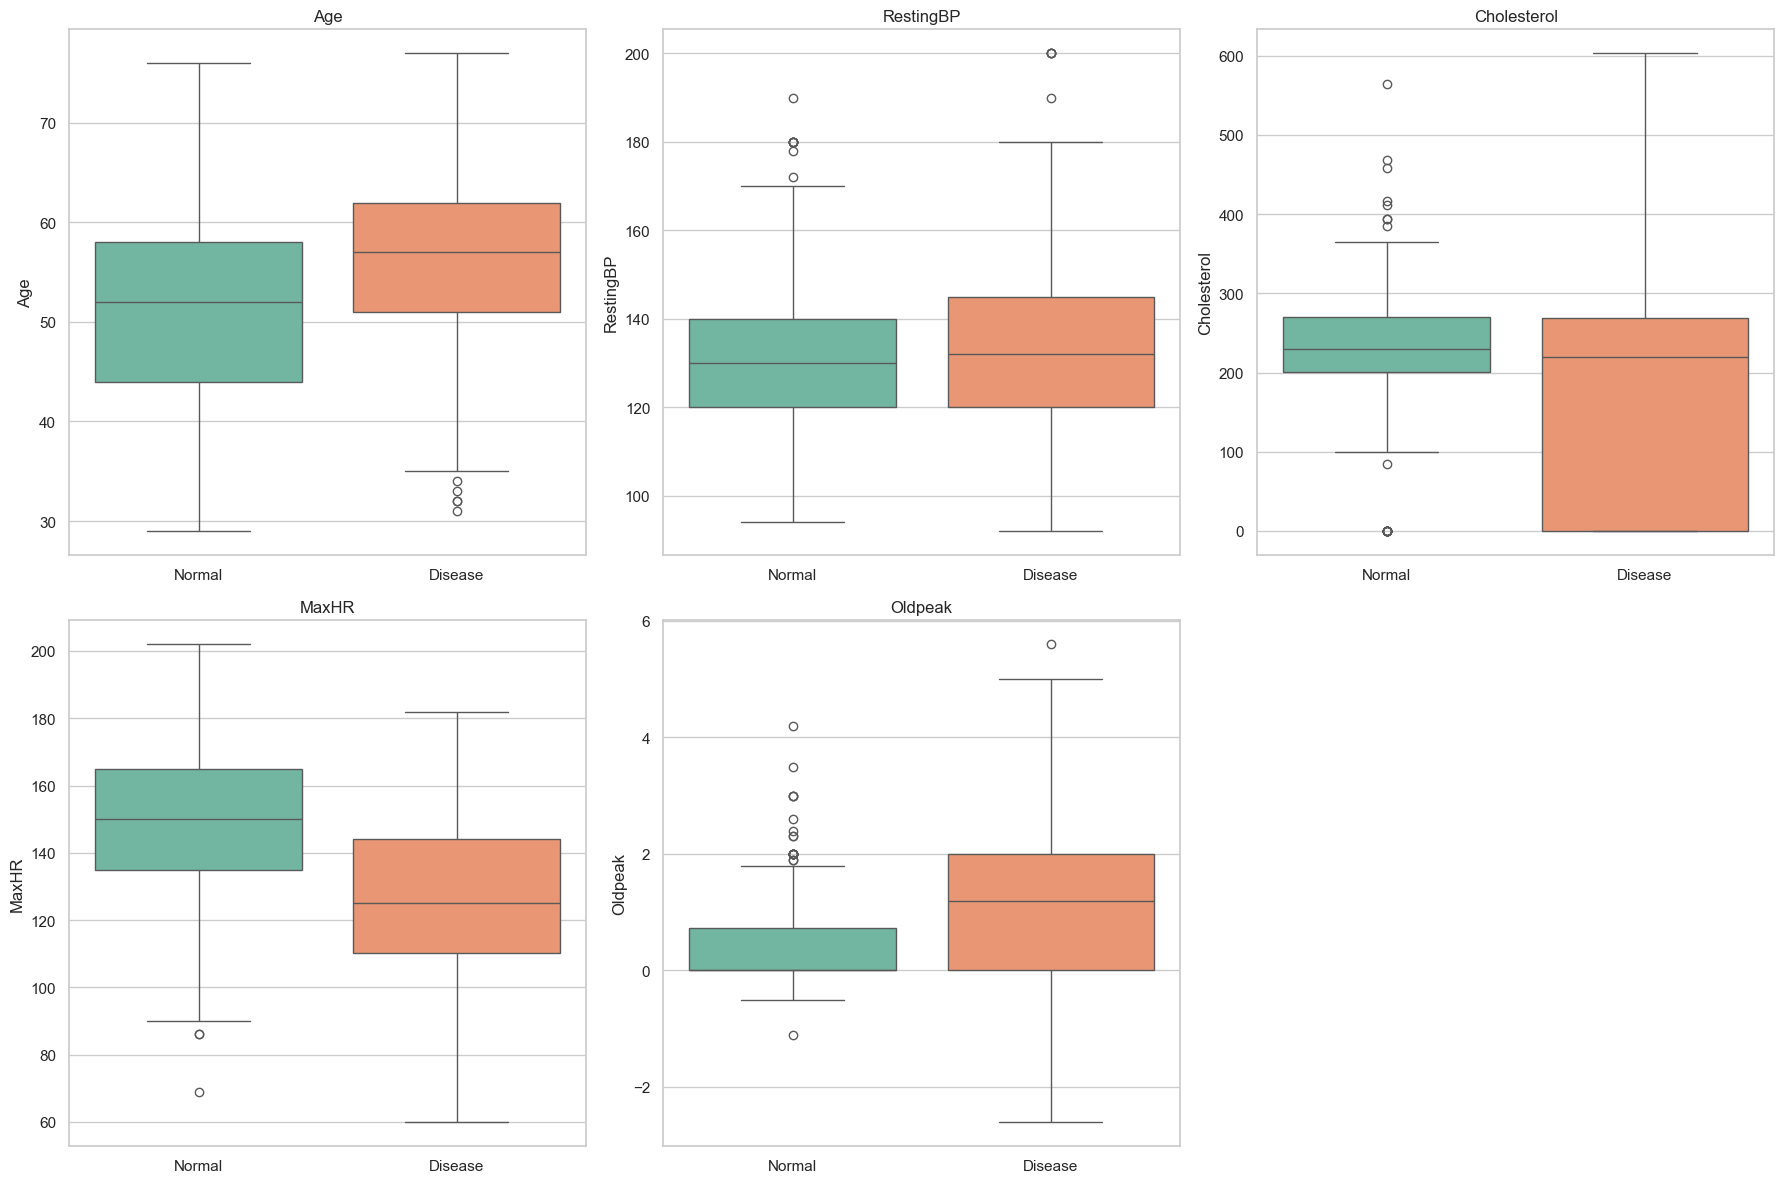

In [80]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, col in zip(axes.flatten(), numerical_cols):

    sns.boxplot(
        data=df,
        x='HeartDisease',
        y=col,
        hue='HeartDisease',
        palette='Set2',
        legend=False,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel('')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal', 'Disease'])

fig.delaxes(axes.flatten()[-1])

plt.tight_layout()
plt.show()

Top-Tier Predictors (High Weight):
- Oldpeak: Excellent separation. A higher Oldpeak value strongly separates the Disease class from the Normal class (which is tightly clustered near 0)
- MaxHR: Strong negative correlation. A visibly lower Maximum Heart Rate is a clear indicator of the Disease class.

Mid-Tier Predictors:
- Age: The median age for the Disease group is noticeably higher (~58) compared to the Normal group (~51). A reliable, albeit standard, predictive feature.

Low-Tier Predictors (Weak Signal):
- RestingBP: The distributions and medians are almost identical between the two classes. It provides very little discriminative power for the model.

CRITICAL DATA WARNING (Cholesterol):
- The Cholesterol boxplot for the Disease class is heavily distorted downward. This reveals that the 0 values (hidden missing data) are disproportionately clustered within the Disease = 1 class. --> NEED TO CHANGE THE cholesterol immediately.

# 4. Multivariate Analysis & Feature Interactions

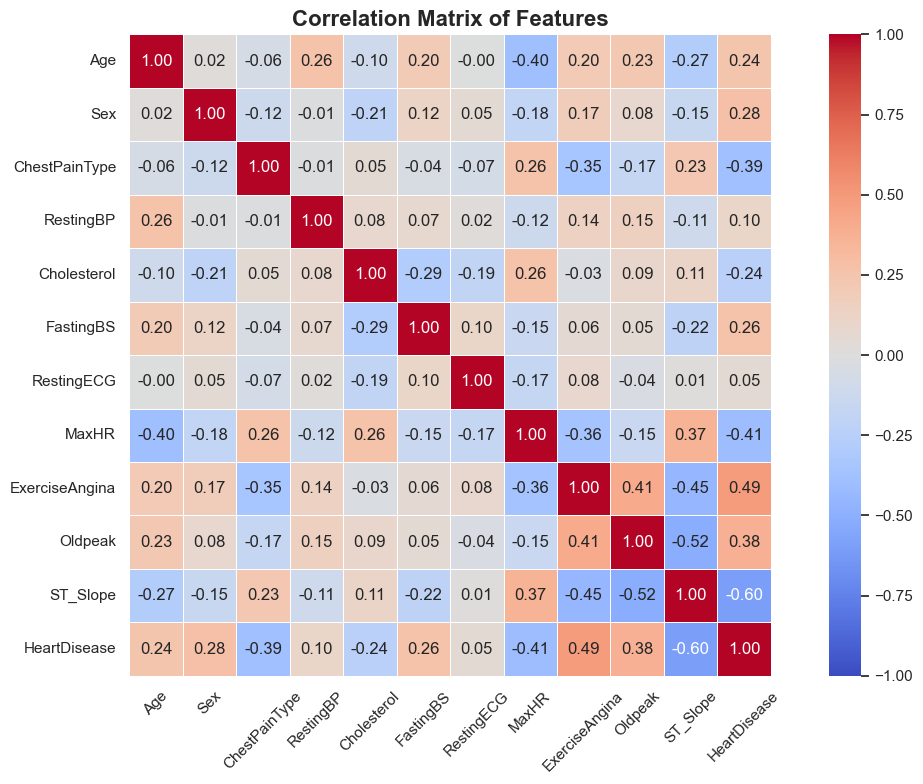

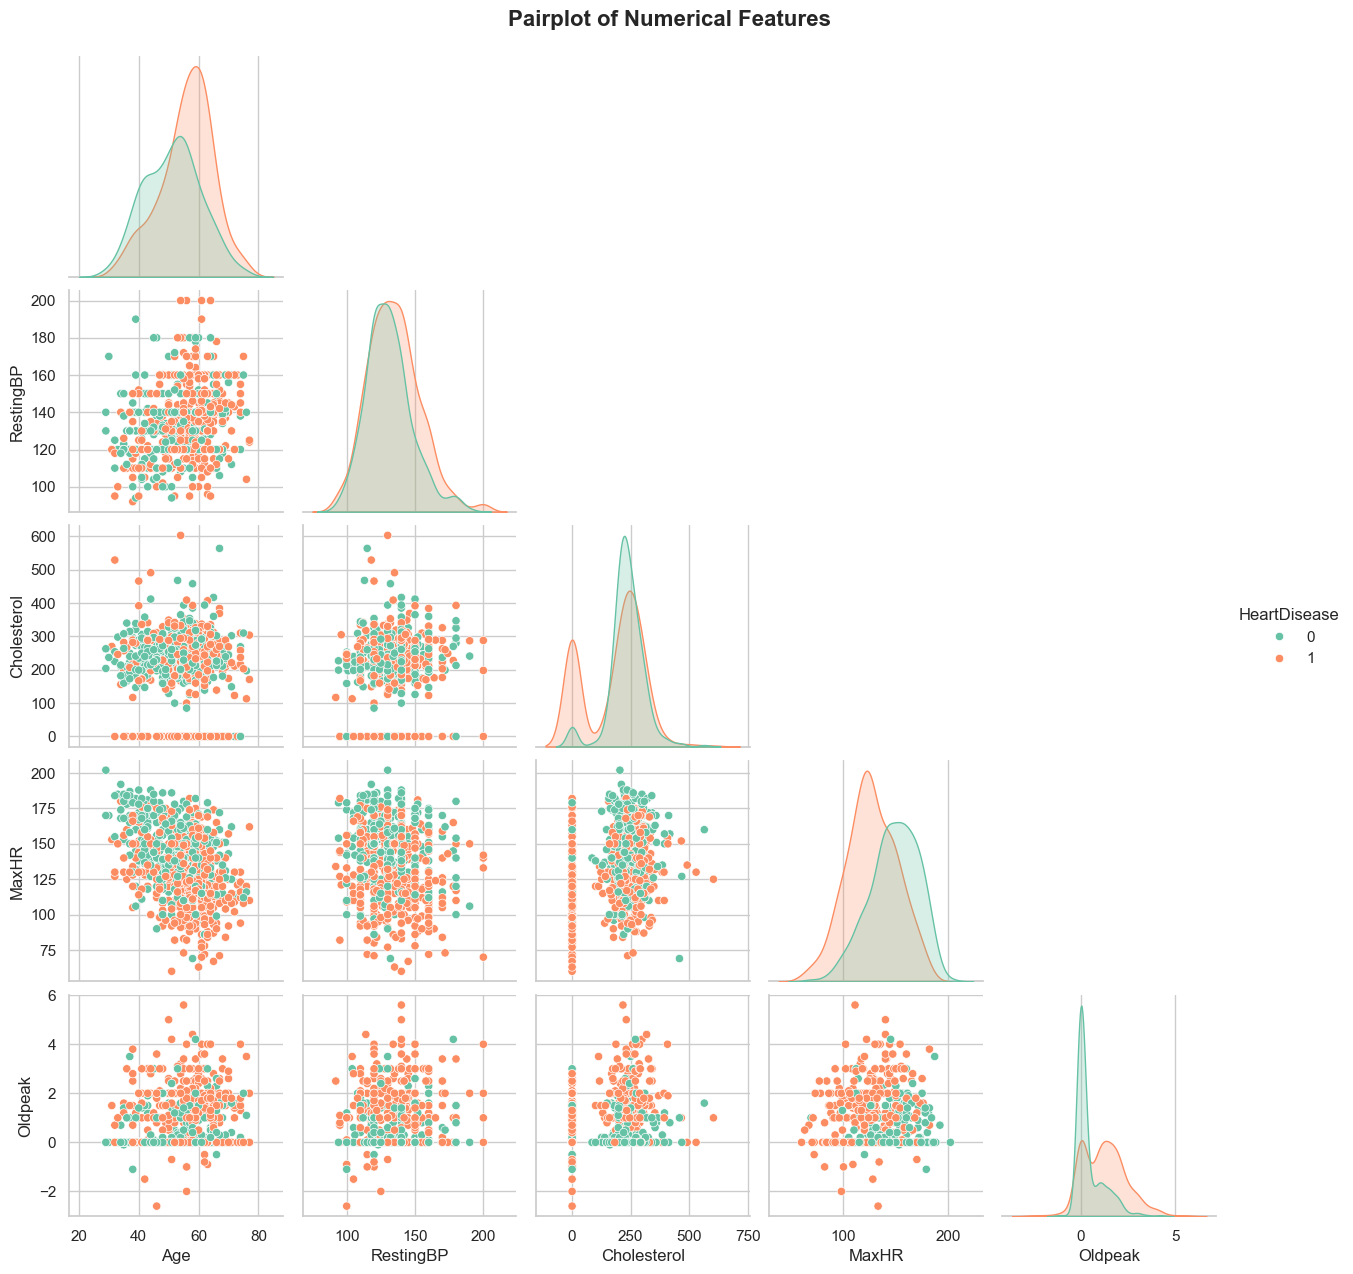

In [86]:
df_corr = df.copy()

label_encoder = LabelEncoder()

for column in df_corr.select_dtypes(include='object').columns:
    df_corr[column] = label_encoder.fit_transform(df_corr[column])

corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Features", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


pairplot_cols = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak',
    'HeartDisease'
]

sns.pairplot(
    data=df[pairplot_cols],
    hue='HeartDisease',
    palette='Set2',
    corner=True,
    diag_kind='kde'
)

plt.suptitle(
    "Pairplot of Numerical Features",
    y=1.02,
    fontsize=16,
    fontweight='bold'
)

plt.show()

4.1. Correlation Matrix Analysis (Model Training Insights)
1. Top Feature Importance (Target Correlation):

The bottom row (HeartDisease) is the most critical. The strongest linear predictors for the model are:

ST_Slope (-0.60): The strongest negative correlation.

ExerciseAngina (0.49): The strongest positive correlation.

MaxHR (-0.41) & ChestPainType (-0.39): Strong negative correlations.

Oldpeak (0.38): Strong positive correlation.

Actionable Step: These 5 features will drive the majority of your model's accuracy. If you need to build a lightweight, fast model, you can train it using only these top 5 features and still achieve high performance.

2. Multicollinearity Check:

We look for correlations between predictors (ignoring the target).

Notable relationships: ST_Slope vs Oldpeak (-0.52), MaxHR vs Age (-0.40), and ST_Slope vs ExerciseAngina (-0.45).

Actionable Step: None of the correlations exceed the dangerous threshold (usually > 0.75 or 0.80). Therefore, strict feature dropping due to multicollinearity is not required. Linear models (like Logistic Regression) will remain stable, and tree-based models (Random Forest, XGBoost) will handle these mild correlations perfectly.

4.2. Pairplot Analysis (Model Training Insights)
1. Complex Decision Boundaries (Algorithm Selection):

Look at any scatter plot grid (e.g., Age vs MaxHR or MaxHR vs Oldpeak). The green dots (Normal) and orange dots (Disease) are heavily mixed and overlapping.

Actionable Step: There is no clear linear line that can perfectly separate the two classes in 2D space. Because of this high overlap, linear algorithms (like standard Logistic Regression or Linear SVM) will likely underperform. You should prioritize non-linear algorithms like XGBoost, Random Forest, or SVM with an RBF kernel, as they can draw complex boundaries around these overlapping clusters.

2. Visual Proof of Data Artifact (Cholesterol):

Look at the scatter plots in the Cholesterol row/column. You can clearly see a dense, straight vertical/horizontal line of orange dots exactly at 0.

Actionable Step: This visually confirms that the Cholesterol = 0 artifact is heavily biased towards the HeartDisease = 1 class. I repeat: You must impute (replace) these zeros before training, otherwise, your model will suffer from data leakage and learn a fake pattern.